# 06. 최종 평가 — test 적용

**이 노트북의 목적**

`04`와 `05`에서 총 5개 실험을 했다. 전부 **val로만** 비교했다. 여기서 최고 모델 하나를 골라
test에 딱 한 번 적용한다.

**왜 test를 아껴야 하는가**

여러 후보를 test로 비교해서 고르면 test가 사실상 두 번째 검증셋이 된다. 그렇게 고른 모델의
test 점수는 "그 test에 가장 잘 맞는 모델을 고른 결과"라 낙관적으로 편향된다.

강의 `4_8`의 스태킹 사례가 정확히 이것이다. `y_test`를 학습에 써서 나온 0.9737은 숫자만 높고
의미가 없었다. 규모는 다르지만 **test 정보가 모델 선택에 새어 든다**는 구조는 같다.

**두 번 돌린다**

`SPLIT_TAG`를 `"v2"`, `"v1"`으로 각각 실행한다. 마지막 절에서 두 결과를 비교해
`03`에서 확인한 근접중복 누수(13그룹 26장)가 실제 성능에 얼마나 영향을 줬는지 잰다.

**출력물**: `metrics/final_{tag}.json`, `probs_{tag}_val.npy`, `probs_{tag}_test.npy`,
`preds_{tag}_test.csv`, `per_class_{tag}.csv`, `figures/12~15*.png`

In [1]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, confusion_matrix,
                             classification_report, roc_auc_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "CUDA 미탐지"
device = torch.device("cuda")

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

SPLIT_TAG   = "v2"          # "v2" 또는 "v1" - 04, 05와 같은 값
NUM_WORKERS = 0             # Windows + Jupyter에서는 반드시 0
BATCH_SIZE  = 128           # 추론만 하므로 배치를 키워도 메모리 여유

OUT = Path("outputs/garbage")
split     = pd.read_csv(OUT / "metrics" / f"split_{SPLIT_TAG}.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
nstats    = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))
exps      = pd.read_csv(OUT / "metrics" / "experiments.csv")

classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

val_df  = split[split.split == "val"].reset_index(drop=True)
test_df = split[split.split == "test"].reset_index(drop=True)

print(f"분할 {SPLIT_TAG} | val {len(val_df):,} | test {len(test_df):,}")
print()
print(exps[exps["split"] == SPLIT_TAG]
      .sort_values("val_macro_f1", ascending=False).to_string(index=False))

분할 v2 | val 2,323 | test 2,323

split      model      exp  best_epoch  val_macro_f1  val_accuracy  val_loss  epochs_run
   v2   ResNet18 finetune          14        0.9318        0.9539    0.1520          15
   v2   ResNet18   frozen          10        0.8728        0.9130    0.2955          10
   v2 GarbageCNN    plain          14        0.7013        0.7520    0.7397          15
   v2 GarbageCNN  sampler          13        0.6811        0.7051    0.8888          15
   v2 GarbageCNN weighted          15        0.6756        0.7064    0.9085          15


## 1. 모델 선정

`experiments.csv`에서 **val macro-F1이 가장 높은 실험**을 자동으로 고른다. 사람이 눈으로 보고
고르면 test 결과를 이미 아는 상태에서 마음이 바뀔 수 있으므로, 규칙을 코드로 박아둔다.

In [2]:
cand = exps[exps["split"] == SPLIT_TAG].sort_values("val_macro_f1", ascending=False)
best = cand.iloc[0]
BEST_MODEL, BEST_EXP = best["model"], best["exp"]

print(f"선정: {BEST_MODEL} / {BEST_EXP}")
print(f"  val macro-F1 {best['val_macro_f1']:.4f} | val accuracy {best['val_accuracy']:.4f}")
print(f"  best epoch {best['best_epoch']} / {best['epochs_run']} 에폭 실행")

if BEST_MODEL == "ResNet18":
    IMAGE_SIZE = 224
    NORM_MEAN, NORM_STD = nstats["imagenet_mean"], nstats["imagenet_std"]
    CKPT = OUT / "models" / f"transfer_{SPLIT_TAG}_{BEST_EXP}.pt"
else:
    IMAGE_SIZE = 128
    NORM_MEAN, NORM_STD = nstats[f"{SPLIT_TAG}_mean"], nstats[f"{SPLIT_TAG}_std"]
    CKPT = OUT / "models" / f"baseline_{SPLIT_TAG}_{BEST_EXP}.pt"

print(f"  입력 {IMAGE_SIZE}px | 체크포인트 {CKPT.name}")
assert CKPT.exists(), f"체크포인트가 없습니다: {CKPT}"

선정: ResNet18 / finetune
  val macro-F1 0.9318 | val accuracy 0.9539
  best epoch 14 / 15 에폭 실행
  입력 224px | 체크포인트 transfer_v2_finetune.pt


In [3]:
eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


class GarbageDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths  = frame["path"].tolist()
        self.labels = frame["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), self.labels[i]


def loader_of(frame):
    return DataLoader(GarbageDataset(frame, eval_tf),
                      batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)


val_loader  = loader_of(val_df)
test_loader = loader_of(test_df)
print(f"val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

val 2,323 | test 2,323


In [4]:
# 04, 05와 동일한 모델 정의 (노트북 독립 실행을 위해 다시 정의)
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(2))


class GarbageCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, p_drop=0.3):
        super().__init__()
        self.features = nn.Sequential(conv_block(3, 32), conv_block(32, 64),
                                      conv_block(64, 128), conv_block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(p_drop), nn.Linear(256, 128),
            nn.ReLU(inplace=True), nn.Dropout(p_drop), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


class TransferModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES, freeze=True, p_drop=0.3):
        super().__init__()
        backbone = models.resnet18(weights=None)
        n_feat = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.frozen = freeze
        self.head = nn.Sequential(nn.Dropout(p_drop), nn.Linear(n_feat, n_classes))

    def train(self, mode=True):
        super().train(mode)
        if self.frozen and mode:
            self.backbone.eval()
        return self

    def forward(self, x):
        return self.head(self.backbone(x))


model = (TransferModel(freeze=(BEST_EXP == "frozen"))
         if BEST_MODEL == "ResNet18" else GarbageCNN())
model.load_state_dict(torch.load(CKPT, map_location=device))
model = model.to(device).eval()
print(f"{BEST_MODEL} / {BEST_EXP} 로드 완료 "
      f"({sum(p.numel() for p in model.parameters()):,} params)")
print("모델 위치:", next(model.parameters()).device, "| eval 모드:", not model.training)

ResNet18 / finetune 로드 완료 (11,182,668 params)
모델 위치: cuda:0 | eval 모드: True


In [5]:
@torch.no_grad()
def predict(model, loader):
    probs, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        probs.append(torch.softmax(model(xb), dim=1).cpu().numpy())
        trues.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(trues)


def metric_pack(trues, probs):
    preds = probs.argmax(axis=1)
    try:
        auc = roc_auc_score(trues, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")
    return {"accuracy":  float(accuracy_score(trues, preds)),
            "macro_f1":  float(f1_score(trues, preds, average="macro", zero_division=0)),
            "macro_rec": float(recall_score(trues, preds, average="macro", zero_division=0)),
            "macro_pre": float(precision_score(trues, preds, average="macro", zero_division=0)),
            "weighted_f1": float(f1_score(trues, preds, average="weighted", zero_division=0)),
            "macro_auc": float(auc)}


t0 = time.time()
val_probs,  val_trues  = predict(model, val_loader)
test_probs, test_trues = predict(model, test_loader)
print(f"추론 완료 {time.time() - t0:.0f}초")

val_m  = metric_pack(val_trues, val_probs)
test_m = metric_pack(test_trues, test_probs)

print(f"\n{'지표':<14}{'val':>10}{'test':>10}{'차이':>10}")
for k in val_m:
    print(f"{k:<14}{val_m[k]:>10.4f}{test_m[k]:>10.4f}{test_m[k] - val_m[k]:>+10.4f}")

추론 완료 76초

지표                   val      test        차이
accuracy          0.9539    0.9453   -0.0086
macro_f1          0.9318    0.9182   -0.0135
macro_rec         0.9300    0.9183   -0.0117
macro_pre         0.9357    0.9208   -0.0149
weighted_f1       0.9539    0.9452   -0.0087
macro_auc         0.9982    0.9981   -0.0001


### val과 test 차이 읽기

두 숫자가 비슷하면 모델이 특정 데이터에 과적합되지 않았다는 뜻이다. test가 val보다 크게 낮으면
val을 보고 에폭·체크포인트를 고르는 과정에서 val에 맞춰진 것이다.

**주의**: 여기서 test가 좋다고 좋아할 일은 아니다. `v1`이라면 근접중복 누수 때문에 test가
부풀려졌을 수 있다. 마지막 절에서 `v1`과 `v2`를 비교해 그 크기를 잰다.

## 2. 정확도 대 macro-F1

이 절이 채점 기준의 **"평가지표를 왜 썼는지 납득"**에 해당한다.

세 가지를 나란히 놓는다.

| 지표 | 계산 | 성질 |
|---|---|---|
| accuracy | 맞힌 수 / 전체 | 다수 클래스가 지배 |
| weighted-F1 | 클래스별 F1을 **장수 비례** 평균 | 다수 클래스가 지배 |
| **macro-F1** | 클래스별 F1을 **동등** 평균 | 소수 클래스도 같은 무게 |

`clothes`가 전체의 34%라 accuracy와 weighted-F1은 그 클래스 성능을 크게 반영한다.
macro-F1은 `brown-glass`(4%)를 통째로 틀리면 1/12만큼 바로 떨어진다.

강의 `pro3`(Cityscapes)에서 픽셀 정확도 0.7405 대 mIoU 0.1549였던 것이 같은 대비다.
그쪽은 클래스가 35개이고 railtrack·bicycle 등이 IoU 0.0이라 격차가 훨씬 컸다.

In [6]:
test_preds = test_probs.argmax(axis=1)

print(classification_report(test_trues, test_preds,
                            target_names=classes, digits=4, zero_division=0))

per_class = pd.DataFrame({
    "label":     classes,
    "support":   [int((test_trues == i).sum()) for i in range(N_CLASSES)],
    "precision": precision_score(test_trues, test_preds, average=None, zero_division=0).round(4),
    "recall":    recall_score(test_trues, test_preds, average=None, zero_division=0).round(4),
    "f1":        f1_score(test_trues, test_preds, average=None, zero_division=0).round(4),
}).sort_values("f1")

per_class["share_%"] = (per_class["support"] / len(test_trues) * 100).round(1)
per_class.to_csv(OUT / "metrics" / f"per_class_{SPLIT_TAG}.csv",
                 index=False, encoding="utf-8")

print(per_class.to_string(index=False))
print(f"\naccuracy      {test_m['accuracy']:.4f}")
print(f"weighted-F1   {test_m['weighted_f1']:.4f}")
print(f"macro-F1      {test_m['macro_f1']:.4f}   <- 주 지표")
print(f"accuracy - macro-F1 = {test_m['accuracy'] - test_m['macro_f1']:+.4f}")

              precision    recall  f1-score   support

     battery     0.9310    0.9574    0.9441       141
  biological     0.9660    0.9530    0.9595       149
 brown-glass     0.9655    0.9231    0.9438        91
   cardboard     0.9766    0.9328    0.9542       134
     clothes     0.9912    0.9975    0.9943       792
 green-glass     0.8462    0.9565    0.8980        92
       metal     0.7868    0.9386    0.8560       114
       paper     0.9487    0.9427    0.9457       157
     plastic     0.8534    0.7674    0.8082       129
       shoes     0.9669    0.9637    0.9653       303
       trash     0.9388    0.8762    0.9064       105
 white-glass     0.8785    0.8103    0.8430       116

    accuracy                         0.9453      2323
   macro avg     0.9208    0.9183    0.9182      2323
weighted avg     0.9466    0.9453    0.9452      2323

      label  support  precision  recall     f1  share_%
    plastic      129     0.8534  0.7674 0.8082      5.6
white-glass      116 

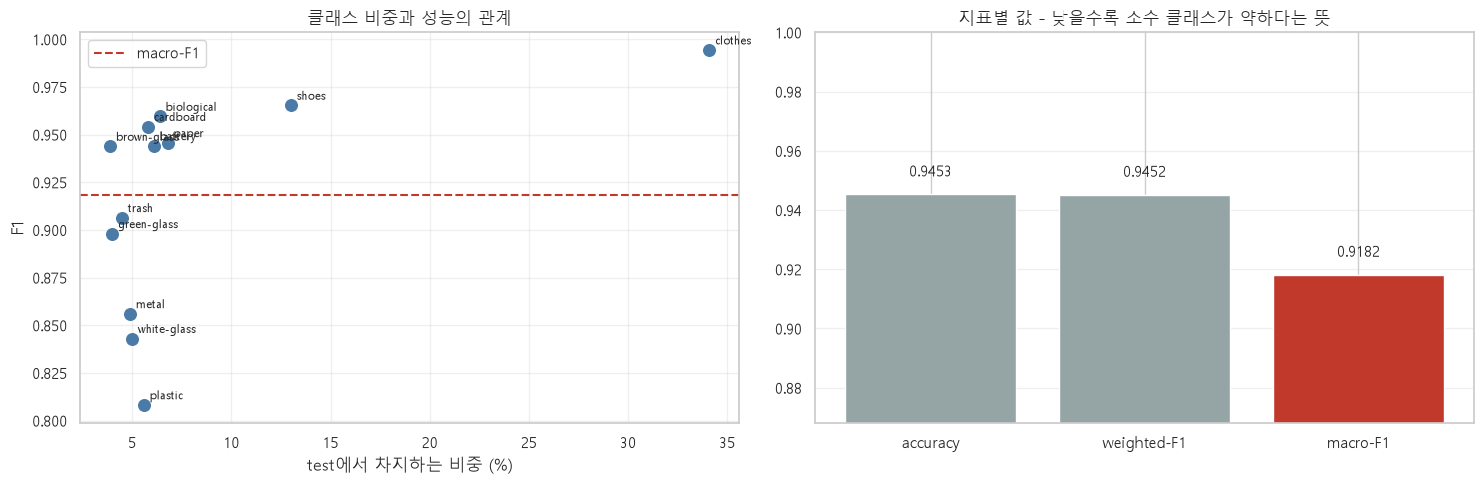

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽: 클래스 비중 대비 F1
ax = axes[0]
ax.scatter(per_class["share_%"], per_class["f1"], s=70, color="#4a7ba7")
for _, r in per_class.iterrows():
    ax.annotate(r["label"], (r["share_%"], r["f1"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(test_m["macro_f1"], ls="--", color="#c0392b", label="macro-F1")
ax.set_xlabel("test에서 차지하는 비중 (%)")
ax.set_ylabel("F1")
ax.set_title("클래스 비중과 성능의 관계")
ax.legend(); ax.grid(alpha=0.3)

# 오른쪽: 세 지표 비교
ax = axes[1]
names = ["accuracy", "weighted_f1", "macro_f1"]
vals = [test_m[k] for k in names]
bars = ax.bar(["accuracy", "weighted-F1", "macro-F1"], vals,
              color=["#95a5a6", "#95a5a6", "#c0392b"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.4f}",
            ha="center", fontsize=11)
ax.set_ylim(min(vals) - 0.05, 1.0)
ax.set_title("지표별 값 - 낮을수록 소수 클래스가 약하다는 뜻")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUT / "figures" / f"12_metric_compare_{SPLIT_TAG}.png", dpi=150)
plt.show()

## 3. 혼동행렬과 오분류 분석

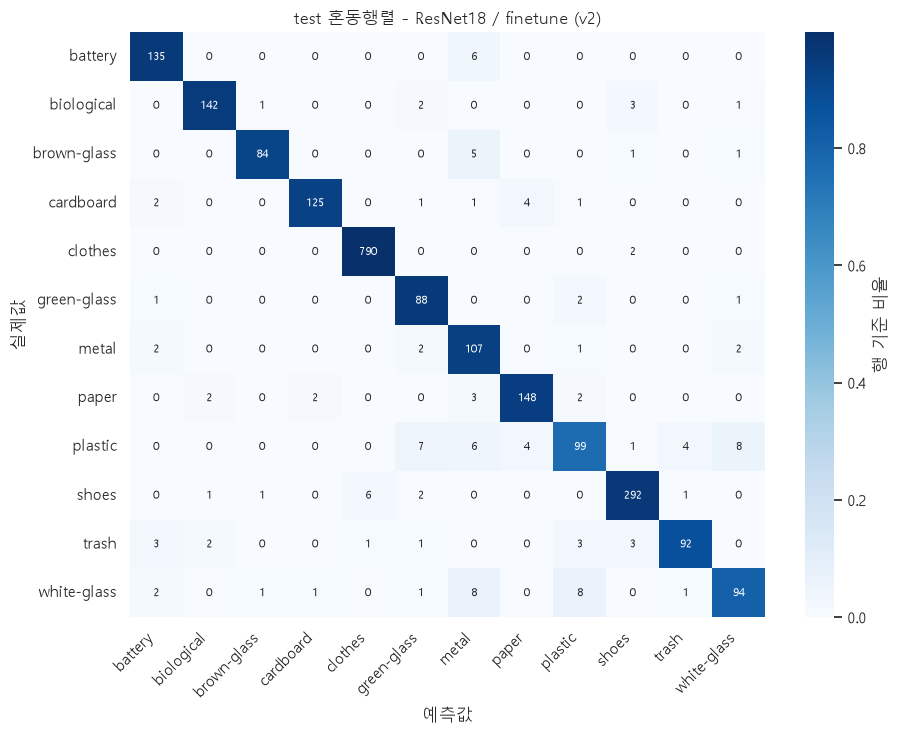

총 오분류 127건 / 2323장

주요 혼동 쌍 (실제 -> 예측)
  plastic        -> white-glass      8건
  white-glass    -> metal            8건
  white-glass    -> plastic          8건
  plastic        -> green-glass      7건
  battery        -> metal            6건
  plastic        -> metal            6건
  shoes          -> clothes          6건
  brown-glass    -> metal            5건
  cardboard      -> paper            4건
  plastic        -> paper            4건
  plastic        -> trash            4건
  biological     -> shoes            3건


In [8]:
cm = confusion_matrix(test_trues, test_preds)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 8}, cbar_kws={"label": "행 기준 비율"})
plt.xlabel("예측값"); plt.ylabel("실제값")
plt.title(f"test 혼동행렬 - {BEST_MODEL} / {BEST_EXP} ({SPLIT_TAG})")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT / "figures" / f"13_test_cm_{SPLIT_TAG}.png", dpi=150)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
pairs = sorted([(classes[i], classes[j], int(off[i, j]))
                for i in range(N_CLASSES) for j in range(N_CLASSES) if off[i, j] > 0],
               key=lambda t: -t[2])
print(f"총 오분류 {int(off.sum())}건 / {len(test_trues)}장\n")
print("주요 혼동 쌍 (실제 -> 예측)")
for a, b, n in pairs[:12]:
    print(f"  {a:14s} -> {b:14s} {n:3d}건")

## 4. 확신도 분석 — `07`의 준비

모델이 얼마나 확신하며 답했는지 본다. 정답일 때와 오답일 때의 확신도 분포가 갈리면,
확신도를 기준으로 "이건 사람이 다시 보자"를 걸러낼 수 있다.

이 분포가 `07`에서 임계값을 정하는 근거가 된다. 강의 `03_평가` 3절의 임계값 조정을
다중분류로 옮긴 것이다.

정답 평균 확신도 0.9567 (n=2,196)
오답 평균 확신도 0.6249 (n=127)

     임계값        커버리지        해당 정확도       보류 장수
    0.50       97.8%       0.9564          52
    0.70       91.9%       0.9817         189
    0.80       88.3%       0.9873         271
    0.90       83.6%       0.9959         380
    0.95       77.7%       0.9978         518
    0.99       61.7%       1.0000         889


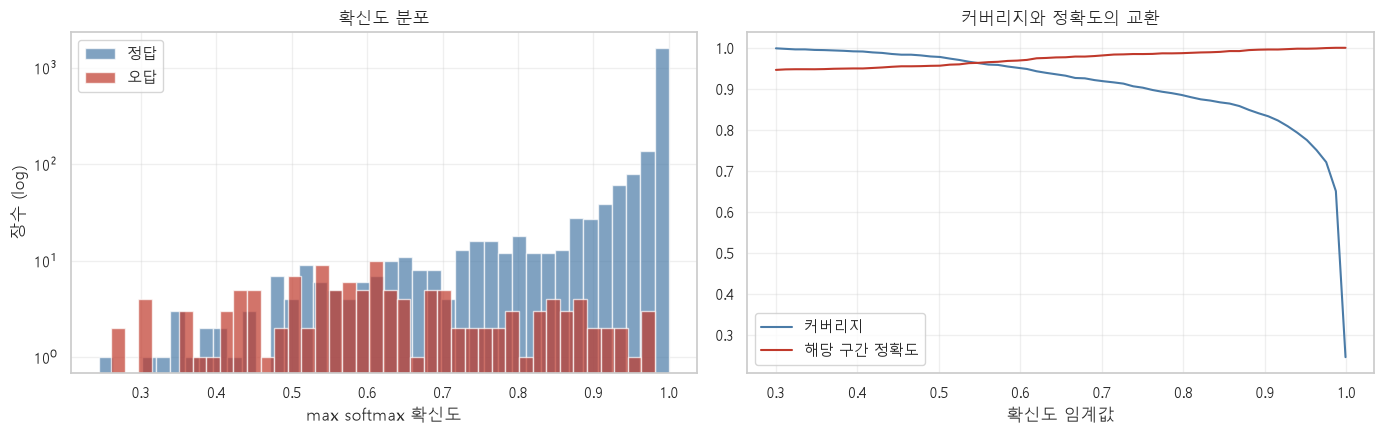

In [9]:
conf = test_probs.max(axis=1)
correct = (test_preds == test_trues)

print(f"정답 평균 확신도 {conf[correct].mean():.4f} (n={correct.sum():,})")
print(f"오답 평균 확신도 {conf[~correct].mean():.4f} (n={(~correct).sum():,})")
print()
print(f"{'임계값':>8}{'커버리지':>12}{'해당 정확도':>14}{'보류 장수':>12}")
for t in [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]:
    m = conf >= t
    print(f"{t:>8.2f}{100 * m.mean():>11.1f}%{correct[m].mean():>13.4f}"
          f"{int((~m).sum()):>12,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(conf[correct], bins=40, alpha=0.7, label="정답", color="#4a7ba7")
axes[0].hist(conf[~correct], bins=40, alpha=0.7, label="오답", color="#c0392b")
axes[0].set_yscale("log")
axes[0].set_xlabel("max softmax 확신도"); axes[0].set_ylabel("장수 (log)")
axes[0].set_title("확신도 분포"); axes[0].legend(); axes[0].grid(alpha=0.3)

ts = np.linspace(0.30, 0.999, 60)
cov = [(conf >= t).mean() for t in ts]
acc = [correct[conf >= t].mean() if (conf >= t).sum() else np.nan for t in ts]
axes[1].plot(ts, cov, label="커버리지", color="#4a7ba7")
axes[1].plot(ts, acc, label="해당 구간 정확도", color="#c0392b")
axes[1].set_xlabel("확신도 임계값"); axes[1].set_title("커버리지와 정확도의 교환")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "figures" / f"14_confidence_{SPLIT_TAG}.png", dpi=150)
plt.show()

## 5. 저장 — `07`, `08`이 쓸 확률 배열

여기서 확률 배열을 파일로 남겨두면 `07`의 임계값 스윕과 `08`의 통계 검정을 **모델을 다시
돌리지 않고** 할 수 있다. 추론에만 몇 분이 걸리므로 실험을 반복할 때 큰 차이가 난다.

`preds_{tag}_test.csv`는 파일 경로를 키로 갖는다. `08`의 McNemar에서 `v1`과 `v2`의 예측을
파일 단위로 짝지어야 하기 때문이다.

In [10]:
np.save(OUT / "metrics" / f"probs_{SPLIT_TAG}_val.npy",  val_probs)
np.save(OUT / "metrics" / f"probs_{SPLIT_TAG}_test.npy", test_probs)

for frame, probs, name in [(val_df, val_probs, "val"), (test_df, test_probs, "test")]:
    rec = pd.DataFrame({
        "path":       frame["path"],
        "filename":   frame["filename"],
        "true_idx":   frame["label_idx"],
        "true_label": frame["final_label"],
        "pred_idx":   probs.argmax(axis=1),
        "pred_label": [classes[i] for i in probs.argmax(axis=1)],
        "confidence": probs.max(axis=1).round(6),
        "correct":    probs.argmax(axis=1) == frame["label_idx"].values,
    })
    rec.to_csv(OUT / "metrics" / f"preds_{SPLIT_TAG}_{name}.csv",
               index=False, encoding="utf-8")
    print(f"preds_{SPLIT_TAG}_{name}.csv 저장 ({len(rec):,}행)")

final = {"split_tag": SPLIT_TAG,
         "model": BEST_MODEL, "exp": BEST_EXP,
         "image_size": IMAGE_SIZE,
         "n_val": int(len(val_df)), "n_test": int(len(test_df)),
         "val": {k: round(v, 4) for k, v in val_m.items()},
         "test": {k: round(v, 4) for k, v in test_m.items()},
         "worst_class": per_class.iloc[0]["label"],
         "worst_f1": float(per_class.iloc[0]["f1"])}

with open(OUT / "metrics" / f"final_{SPLIT_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(final, f, ensure_ascii=False, indent=2)

print()
print(json.dumps(final, ensure_ascii=False, indent=2))

preds_v2_val.csv 저장 (2,323행)
preds_v2_test.csv 저장 (2,323행)

{
  "split_tag": "v2",
  "model": "ResNet18",
  "exp": "finetune",
  "image_size": 224,
  "n_val": 2323,
  "n_test": 2323,
  "val": {
    "accuracy": 0.9539,
    "macro_f1": 0.9318,
    "macro_rec": 0.93,
    "macro_pre": 0.9357,
    "weighted_f1": 0.9539,
    "macro_auc": 0.9982
  },
  "test": {
    "accuracy": 0.9453,
    "macro_f1": 0.9182,
    "macro_rec": 0.9183,
    "macro_pre": 0.9208,
    "weighted_f1": 0.9452,
    "macro_auc": 0.9981
  },
  "worst_class": "plastic",
  "worst_f1": 0.8082
}


## 6. v1 vs v2 — 데이터 누수의 실제 크기

**두 태그를 모두 실행한 뒤에만 결과가 나온다.** 한쪽만 돌렸다면 이 절은 건너뛴다.

`03`에서 `v1`은 근접중복 그룹 13개(26장)가 train/test에 갈라져 있었고 `v2`는 0개였다.
같은 데이터, 같은 모델, 같은 하이퍼파라미터에서 분할 방식만 달랐으므로,
성능 차이가 있다면 원인은 그것뿐이다.

In [11]:
paths = {t: OUT / "metrics" / f"final_{t}.json" for t in ["v1", "v2"]}

if all(p.exists() for p in paths.values()):
    f1 = json.load(open(paths["v1"], encoding="utf-8"))
    f2 = json.load(open(paths["v2"], encoding="utf-8"))

    rows = []
    for k in ["accuracy", "macro_f1", "weighted_f1", "macro_rec", "macro_auc"]:
        rows.append({"metric": k,
                     "v1 (누수 있음)": round(f1["test"][k], 4),
                     "v2 (누수 없음)": round(f2["test"][k], 4),
                     "차이 (v1-v2)": round(f1["test"][k] - f2["test"][k], 4)})
    comp = pd.DataFrame(rows)
    print(comp.to_string(index=False))
    print(f"\nv1 모델: {f1['model']}/{f1['exp']} | v2 모델: {f2['model']}/{f2['exp']}")

    d = comp.loc[comp.metric == "macro_f1", "차이 (v1-v2)"].iloc[0]
    print(f"\nmacro-F1 기준 차이 {d:+.4f}")
    print("양수라면 v1이 부풀려진 것이고, 그만큼이 근접중복 누수의 몫입니다.")
    print("이 차이가 통계적으로 유의한지는 08에서 검정합니다.")

    x = np.arange(len(comp)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - w/2, comp["v1 (누수 있음)"], w, label="v1 단순 분할", color="#e8a33d")
    ax.bar(x + w/2, comp["v2 (누수 없음)"], w, label="v2 그룹 인지", color="#4a7ba7")
    ax.set_xticks(x); ax.set_xticklabels(comp["metric"], rotation=20)
    ax.set_ylim(0.8, 1.0); ax.legend(); ax.grid(alpha=0.3, axis="y")
    ax.set_title("분할 방식에 따른 test 성능 차이")
    plt.tight_layout()
    plt.savefig(OUT / "figures" / "15_leakage_effect.png", dpi=150)
    plt.show()
else:
    missing = [t for t, p in paths.items() if not p.exists()]
    print(f"아직 실행하지 않은 태그: {missing}")
    print("SPLIT_TAG를 바꿔 04 -> 05 -> 06을 다시 돌린 뒤 이 셀을 실행하세요.")

아직 실행하지 않은 태그: ['v1']
SPLIT_TAG를 바꿔 04 -> 05 -> 06을 다시 돌린 뒤 이 셀을 실행하세요.


## 정리

| 항목 | 내용 |
|---|---|
| 선정 규칙 | val macro-F1 최고 (코드로 자동 선택) |
| test 사용 | 이 노트북에서 단 한 번 |
| 주 지표 | macro-F1 |
| 함께 보고 | accuracy, weighted-F1, macro-AUC |

**다음 두 노트북이 채점 기준 두 항목을 담당한다.**

- `07_Threshold` — 임계값에 따른 지표 변화
- `08_Hypothesis` — 가설검정

둘 다 여기서 저장한 `probs_*.npy`와 `preds_*.csv`를 읽어 쓰므로 모델을 다시 돌릴 필요가 없다.

→ `07_Threshold.ipynb`